# Sentinel-1 SAR speckle filtering (Lee filter)

SAR backscatter has multiplicative **speckle** - a grainy noise that hurts thresholding and segmentation. Here we read VV from the annual Sentinel-1 (GEE) backscatter image and apply a classic adaptive **Lee filter** (pure numpy/scipy).

This notebook uses the **bundled demo pack** (`hackathon_demo_data/`, the **D_Chablis_Vineyard** AOI) — local files, no S3, no credentials.

Demo file: `sentinel1_gee/2023/sentinel1_D_Chablis_Vineyard_2023.tif` - annual VV/VH in **dB**, ~10 m (decimated to ~700 px for the demo).

> The GEE product is stored in **dB**. Convert to **linear** power (`10**(dB/10)`), filter in
> linear, then convert back to **dB** (`10*log10`) for display - filtering in dB (log) space
> biases the result.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import rioxarray  # noqa: F401  (registers the .rio accessor)
from scipy.ndimage import uniform_filter

# Local demo pack - no S3, no credentials. See the repo README to download/unzip it.
DATA_DIR = Path("hackathon_demo_data")

In [2]:
AOI = "D_Chablis_Vineyard"
uri = DATA_DIR / "sentinel1_gee" / "2023" / f"sentinel1_{AOI}_2023.tif"
s1 = rioxarray.open_rasterio(uri)            # (band, y, x); band 1 = VV, band 2 = VH, in dB
print("bands:", list(s1.long_name), "| dims:", dict(s1.sizes))

vv_db = s1.isel(band=0).values.astype("float32")   # VV in dB
vv = 10.0 ** (vv_db / 10.0)                          # dB -> linear power for filtering
print("year: 2023 | finite frac:", round(float(np.isfinite(vv).mean()), 3))

bands: ['VV', 'VH'] | dims: {'band': 2, 'y': 429, 'x': 705}
year: 2023 | finite frac: 0.733


## Lee filter

Each output pixel blends towards the local mean by a weight derived from local vs global variance: smooth where the scene is uniform (kills speckle), but keep the original value near edges (high local variance). NaN-safe via a validity mask.

In [3]:
def lee_filter(img, size=7):
    """Adaptive Lee speckle filter on linear backscatter (NaN-safe)."""
    img = img.astype("float32")
    nan = ~np.isfinite(img)
    filled = np.where(nan, 0.0, img)
    valid = (~nan).astype("float32")

    count = uniform_filter(valid, size)
    count[count == 0] = np.nan
    local_mean = uniform_filter(filled, size) / count
    local_sqr = uniform_filter(filled ** 2, size) / count
    local_var = np.clip(local_sqr - local_mean ** 2, 0, None)

    overall_var = np.nanvar(img)
    weight = local_var / (local_var + overall_var)
    out = local_mean + weight * (np.where(nan, local_mean, img) - local_mean)
    out[nan] = np.nan
    return out

vv_filt = lee_filter(vv, size=7)             # filter in linear power

# back to dB for display (vv_db is already dB, straight from the source)
to_db = lambda a: 10 * np.log10(np.where(a > 0, a, np.nan))
vv_filt_db = to_db(vv_filt)

## Before / after

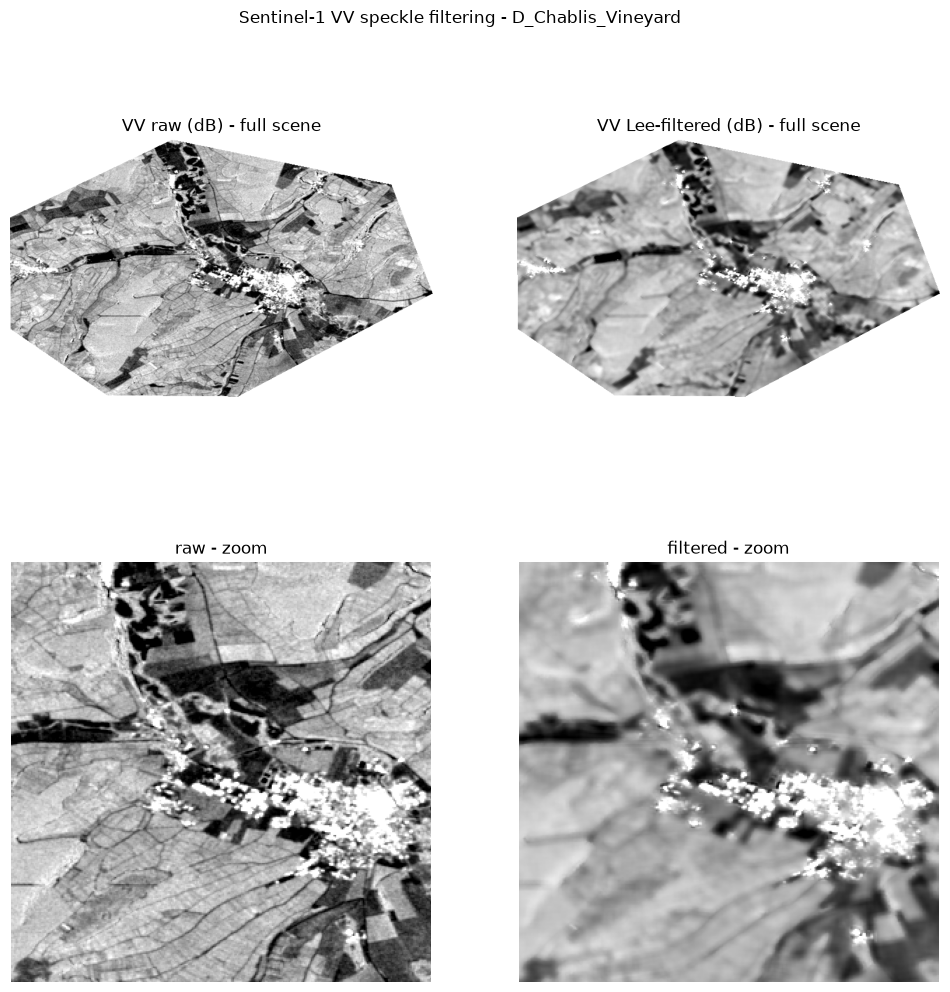

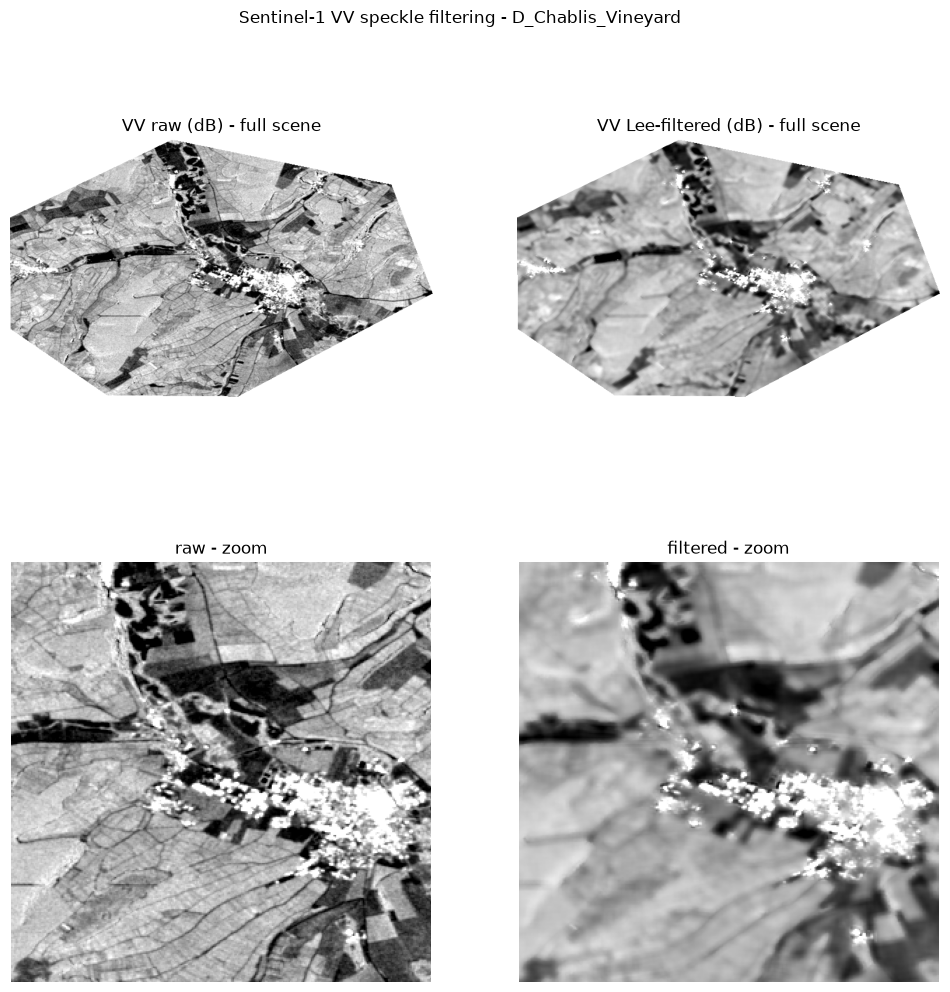

In [4]:
vmin, vmax = np.nanpercentile(vv_db, [2, 98])

# a generous central patch so the zoom keeps context (raw vs filtered, same area)
y0, x0 = vv.shape[0] // 2 - 150, vv.shape[1] // 2 - 150
sl = (slice(y0, y0 + 300), slice(x0, x0 + 300))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(vv_db, cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("VV raw (dB) - full scene")
axes[0, 1].imshow(vv_filt_db, cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("VV Lee-filtered (dB) - full scene")
axes[1, 0].imshow(vv_db[sl], cmap="gray", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("raw - zoom")
axes[1, 1].imshow(vv_filt_db[sl], cmap="gray", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("filtered - zoom")
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle(f"Sentinel-1 VV speckle filtering - {AOI}", y=0.92)
fig.savefig("03_sar_despeckle.png", dpi=120, bbox_inches="tight")
fig